In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from datetime import datetime, date, timedelta
import seaborn as sns
import shapely
import plotting

In [2]:
gdf_track_info = gpd.read_parquet("../data/cleaned/track_info.parquet")
gdf_track_info

,track_file,track_file_datetime,track_file_date,start_datetime,end_datetime,num_pauses,total_duration,active_duration,total_distance (mi),average_pace (min/mi),total_ascent (m),total_descent (m),year,season,in_stc,start_point,end_point,track_line
0,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00-05:00,2019-06-10,2019-06-10 11:57:42+00:00,2019-06-10 12:46:10+00:00,0,0 days 00:48:28,0 days 00:48:28,3.060933,8.542777,39.011887,-38.079392,Freshman,Summer Training,True,POINT (-88.32154 41.91101),POINT (-88.32166 41.9109),"MULTILINESTRING ((-88.32154 41.91101, -88.3215..."
1,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00-05:00,2019-06-11,2019-06-11 11:59:03+00:00,2019-06-11 12:32:23+00:00,5,0 days 00:33:20,0 days 00:33:10,3.154848,8.785222,60.890730,-61.285231,Freshman,Summer Training,True,POINT (-88.34764 41.928),POINT (-88.34792 41.92783),"MULTILINESTRING ((-88.34764 41.928, -88.34764 ..."
2,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00-05:00,2019-06-12,2019-06-12 11:53:36+00:00,2019-06-12 12:35:13+00:00,5,0 days 00:41:43,0 days 00:30:46,2.521019,8.567542,68.381334,-63.546495,Freshman,Summer Training,True,POINT (-88.32153 41.91251),POINT (-88.32172 41.911),"MULTILINESTRING ((-88.32153 41.91251, -88.3215..."
3,/Users/ryansponzilli/Developer/Python Projects...,2019-06-17 07:22:00-05:00,2019-06-17,2019-06-17 11:52:32+00:00,2019-06-17 12:22:32+00:00,0,0 days 00:30:00,0 days 00:30:00,2.981428,9.099587,43.081880,-42.863923,Freshman,Summer Training,True,POINT (-88.32145 41.911),POINT (-88.32154 41.91096),"MULTILINESTRING ((-88.32145 41.911, -88.32143 ..."
4,/Users/ryansponzilli/Developer/Python Projects...,2019-06-18 07:19:00-05:00,2019-06-18,2019-06-18 11:53:58+00:00,2019-06-18 12:19:21+00:00,3,0 days 00:25:23,0 days 00:25:03,2.343798,9.394596,49.200207,-46.531003,Freshman,Summer Training,True,POINT (-88.35416 41.92575),POINT (-88.34797 41.92783),"MULTILINESTRING ((-88.35416 41.92575, -88.3541..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1028,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:10:00-05:00,2023-05-04,2023-05-04 19:54:31+00:00,2023-05-04 20:10:21+00:00,3,0 days 00:15:50,0 days 00:15:19,2.016680,7.594214,11.909316,-11.700034,Senior,Track Season,True,POINT (-88.27989 41.92867),POINT (-88.27976 41.92838),"MULTILINESTRING ((-88.27989 41.92867, -88.2798..."
1029,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:42:00-05:00,2023-05-04,2023-05-04 20:24:20+00:00,2023-05-04 20:42:07+00:00,5,0 days 00:13:23,0 days 00:04:57,0.986106,4.937965,2.089703,-1.547136,Senior,Track Season,True,POINT (-88.27658 41.92847),POINT (-88.27658 41.92851),"MULTILINESTRING ((-88.27658 41.92847, -88.2765..."
1030,/Users/ryansponzilli/Developer/Python Projects...,2023-05-05 15:11:00-05:00,2023-05-05,2023-05-05 19:44:31+00:00,2023-05-05 20:11:23+00:00,4,0 days 00:26:52,0 days 00:25:05,3.484011,7.014577,21.619114,-22.143583,Senior,Track Season,True,POINT (-88.27988 41.92846),POINT (-88.27952 41.9282),"MULTILINESTRING ((-88.27988 41.92846, -88.2798..."
1031,/Users/ryansponzilli/Developer/Python Projects...,2023-05-06 11:15:00-05:00,2023-05-06,2023-05-06 15:58:42+00:00,2023-05-06 16:15:16+00:00,5,0 days 00:16:34,0 days 00:15:10,1.952713,7.702272,19.363362,-19.573921,Senior,Track Season,True,POINT (-88.32198 41.95005),POINT (-88.32167 41.95012),"MULTILINESTRING ((-88.32198 41.95005, -88.3219..."


In [3]:
pause_line = gdf_track_info.loc[gdf_track_info['start_datetime'] > pd.to_datetime(datetime(2023, 2, 7), utc=True)][0:1]
pause_line

,track_file,track_file_datetime,track_file_date,start_datetime,end_datetime,num_pauses,total_duration,active_duration,total_distance (mi),average_pace (min/mi),total_ascent (m),total_descent (m),year,season,in_stc,start_point,end_point,track_line
947,/Users/ryansponzilli/Developer/Python Projects...,2023-02-07 15:48:00-06:00,2023-02-07,2023-02-07 21:13:31+00:00,2023-02-07 21:48:02+00:00,1,0 days 00:34:31,0 days 00:21:04,2.433688,7.439789,18.098955,-18.544787,Senior,Track Season,True,POINT (-88.27581 41.9252),POINT (-88.27562 41.92512),"MULTILINESTRING ((-88.27581 41.9252, -88.27581..."


In [4]:
# parse file
gdf = gpd.read_file(pause_line['track_file'].iloc[0], layer="track_points")
gdf = gdf[["time", "ele", "geometry"]]
gdf["time"] = pd.to_datetime(gdf["time"])
gdf = gdf.rename(columns={"time": "datetime", "ele": "elevation"})

# create helper columns
gdf['dt'] = gdf["datetime"].diff()
gdf_utm = gdf.to_crs(gdf.estimate_utm_crs())
gdf["dx"] = gdf_utm["geometry"].distance(gdf_utm["geometry"].shift())

# split into segments at pause indices
pause_idx = list(gdf.loc[gdf['dt'] > timedelta(seconds=1)].index)
gdf['pause_segment'] = None
segment_idx = ([0] + pause_idx + [len(gdf)])
for i in range(len(segment_idx) - 1):
    gdf.loc[segment_idx[i]:segment_idx[i+1], 'pause_segment'] = i

# remove segments less than 5 seconds
gdf = gdf.groupby("pause_segment", group_keys=False).filter(lambda x: len(x) >= 5)

# calculate pace for each pause segment separately
def calculate_rolling_pace(gdf):
    # use a 10 second rolling window for calculating pace
    gdf["pace (min/mi)"] = (gdf["dt"].cumsum().dt.total_seconds() / 60).diff(10) / (gdf["dx"].cumsum() / 1609).diff(10)
    # backfill nans that resulted from the rolling window
    gdf["pace (min/mi)"] = gdf["pace (min/mi)"].bfill()
    return gdf
gdf = gdf.groupby('pause_segment').apply(calculate_rolling_pace).reset_index().drop(columns=["level_1"], errors='ignore')

gdf

,pause_segment,datetime,elevation,geometry,dt,dx,pace (min/mi)
0,0,2023-02-07 21:13:31+00:00,236.657103,POINT (-88.27581 41.9252),NaT,NaN,24.171964
1,0,2023-02-07 21:13:32+00:00,236.608273,POINT (-88.27581 41.92519),0 days 00:00:01,1.199533,24.171964
2,0,2023-02-07 21:13:33+00:00,236.587713,POINT (-88.2758 41.92518),0 days 00:00:01,1.385900,24.171964
3,0,2023-02-07 21:13:34+00:00,236.484079,POINT (-88.27578 41.92517),0 days 00:00:01,1.437056,24.171964
4,0,2023-02-07 21:13:35+00:00,236.343193,POINT (-88.27577 41.92516),0 days 00:00:01,1.437057,24.171964
...,...,...,...,...,...,...,...
1261,1,2023-02-07 21:47:58+00:00,236.227632,POINT (-88.27554 41.92515),0 days 00:00:01,2.226416,10.166711
1262,1,2023-02-07 21:47:59+00:00,236.210292,POINT (-88.27556 41.92514),0 days 00:00:01,2.098783,10.517239
1263,1,2023-02-07 21:48:00+00:00,236.194119,POINT (-88.27559 41.92513),0 days 00:00:01,1.942224,10.926442
1264,1,2023-02-07 21:48:01+00:00,236.178369,POINT (-88.27561 41.92513),0 days 00:00:01,1.787341,11.447533


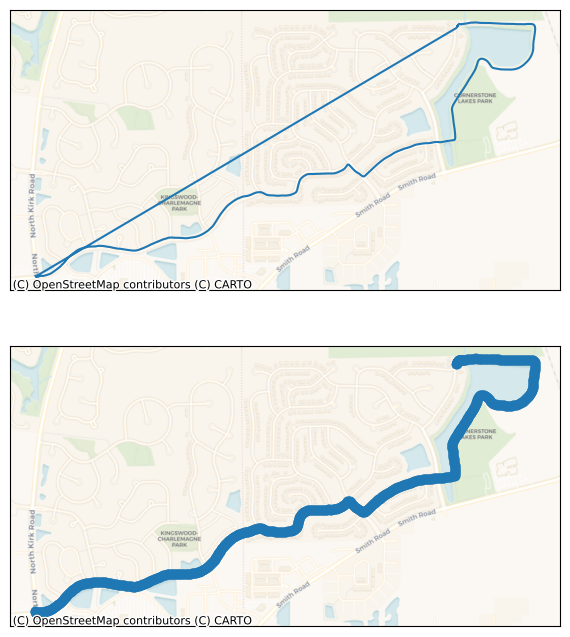

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(8,8))
plotting.plot_map(gpd.read_file(pause_line['track_file'].iloc[0], layer="tracks"), ax[0])
plotting.plot_map(gdf, ax[1])

1
0 days 00:34:31
0 days 00:21:04
2.4336877055889525
7.4397892960859755
18.098955000000046
-18.544787000000042


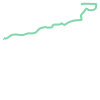

In [6]:
# calculate number of pauses, where a pause is defined as dt > 1 second
num_pauses = len(gdf.loc[gdf['dt'] > timedelta(seconds=1)])
print(num_pauses)

# calculate the total duration, defined as the time between starting and ending the activity
total_duration = gdf['dt'].sum()
print(total_duration)

# calculate the active duration, defined as the total time minus any pauses
active_duration = gdf.loc[gdf['dt'] == timedelta(seconds=1), 'dt'].sum()
print(active_duration)

# calculate total distance, excluding pauses
total_distance_miles = gdf.loc[(gdf['dt'] == timedelta(seconds=1)), 'dx'].sum() / 1609
print(total_distance_miles)

# calculate average pace, exclude any pace over 10 min/mi since those are not representative of actual running
average_pace = gdf.loc[gdf["pace (min/mi)"] < 10, "pace (min/mi)"].mean()
print(average_pace)

# calculate total ascent, excluding pauses
total_ascent = gdf.loc[(gdf['dt'] == timedelta(seconds=1)), 'elevation'].diff().loc[gdf['elevation'].diff() > 0].sum()
print(total_ascent)

# calculate total descent, excluding pauses
total_descent = gdf.loc[(gdf['dt'] == timedelta(seconds=1)), 'elevation'].diff().loc[gdf['elevation'].diff() < 0].sum()
print(total_descent)

# split each pause segment into a LineString within a MultiLineString
fixed_track_line = shapely.MultiLineString([shapely.LineString(group['geometry']) for _, group in gdf.groupby('pause_segment')])
display(fixed_track_line)